<a href="https://colab.research.google.com/github/RyMack05/ML-fundamentals-2026/blob/main/assignment_1_Ryann_Mack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 – ML Fundamentals 2026

##Author: Ryann Mack

###Goal:
Given client and campaign information available at the time of contact, predict whether the client subscribes to a term deposit (i.e., a type of short-term investment)

### Overview

In this assignment, I use the UCI Bank Marketing dataset to predict whether a client subscribes to a term deposit (**y ∈ {yes, no}**), based only on information available at the time of contact.

## Order of Data Preparation

1. **Identifying the prediction target**
2. **EDA**
3. **Data splitting**
4. **Managing missing values**
5. **Feature selection**
6. **Encoding categorical variables**
7. **Feature scaling**
8. **Adressing class imbalance**
9. **Training logistic regression**
10. **Evaluation + Zero rule comparison**

In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [141]:
url = "https://raw.githubusercontent.com/RyMack05/ML-fundamentals-2026/refs/heads/main/bank-additional.csv"

df = pd.read_csv(url, sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


# 1. Identifying the Prediction Target

Here we look at the table above to determine which variable is our target looking at the 3 most likely variables.

* y
  * The objective of the marketing campaign was to determine whether the client subscribes to a term deposit. Therefore, y directly represents the business objective
* default
  * Also contains yes/no condition, but isn't the target
* poutcome
  * Seems related to the target as well, but isn't the target

In [142]:
print("Unique y values:", df["y"].unique())
print("\nCounts:\n", df["y"].value_counts())
print("\nProportions:\n", df["y"].value_counts(normalize=True))

Unique y values: ['no' 'yes']

Counts:
 y
no     3668
yes     451
Name: count, dtype: int64

Proportions:
 y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


We use groupby(**y**) because the problem asks us to predict whether a client subscribes to a term deposit in the current campaign, and **y** directly represents that outcome. Variables like **default** and **poutcome** describe financial status or past campaign results, not the current subscription decision.


In [143]:
df.groupby("y")["default"].describe()

,count,unique,top,freq
y,,,,
no,3668,3,no,2913
yes,451,2,no,402


default:

no: 2913 (in y=no)

no: 402  (in y=yes)

--

That only tells us:
- Among subscribers and non-subscribers, most people are not in default.

That doesn’t mean default is the target.

--

default means:
- Does the client have credit in default?

--

This is the financial status.
- It’s not the outcome of the marketing campaign.

--

Even if it’s binary (yes/no), it’s not the prediction goal.

In [144]:
df.groupby("y")["poutcome"].describe()

,count,unique,top,freq
y,,,,
no,3668,3,nonexistent,3231
yes,451,3,nonexistent,292


**poutcome** may appear to be a valid target because it contains values such as *sucess, failure, and nonexistent*. However poutcome refers to the result of a previous marketing campaign, and not the current one.
* Informative but not our target

### Why **y** is the correct target
**y** records whether the client subscribed to the term deposit after being contacted, which matches the campaign objective.

### Two variables that could superficially look like targets, but are not
1) **default** — Represents the financial status of a customer, but isn't the target
2) **poutcome** — May have a yes and no, but this is in regards to the outcome of previous campaigns, which again, means this isn't our target

# 2. Exploratory Data Analysis (EDA)

- Inspect dataset structure and data types.
- Separate numerical vs categorical variables.
- Check for missing values (explicit **NaNs** and implicit **"unknown"**).
- Visualize at least 2 numerical and 2 categorical variables.
- Identify variables requiring special consideration (leakage risk).

## Why EDA is Here
We do EDA before splitting because:
- We need to understand the dataset to understand how we will ensure we clean the data properly
- EDA helps us understand what preprocessing we will need later.
- We do NOT compute train-only fitted statistics here (that happens after splitting).

The dataset contains 4119 observations and 21 variables. Each row represents a client contacted during a marketing campaign.

We have many objects which we will need to encode later in the notebook

In [145]:
print("Shape:", df.shape)
display(df.dtypes)

Shape: (4119, 21)


,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


In [146]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("\nCategorical columns:", categorical_cols)

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [147]:
# Explicit missingness (NaN)
display(df.isnull().sum().sort_values(ascending=False).head(15))

# Implicit missingness ("unknown")
unknown_cols = [c for c in categorical_cols if "unknown" in df[c].unique()]
print("Columns containing 'unknown':", unknown_cols)

unknown_rates_full = pd.DataFrame({
    "col": unknown_cols,
    "unknown_count": [(df[c] == "unknown").sum() for c in unknown_cols],
    "unknown_pct": [(df[c] == "unknown").mean() for c in unknown_cols],
}).sort_values("unknown_pct", ascending=False)

display(unknown_rates_full)

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


Columns containing 'unknown': ['job', 'marital', 'education', 'default', 'housing', 'loan']


,col,unknown_count,unknown_pct
3,default,803,0.194950
2,education,167,0.040544
4,housing,105,0.025492
5,loan,105,0.025492
0,job,39,0.009468
1,marital,11,0.002671


There are no NULL values, we check for missing values next

The columns: ['job', 'marital', 'education', 'default', 'housing', 'loan']

These are the columns that have unknown values.

To handle these we will create a separate column like 'default_unknown' so our model can see if something being 'unknown' is significant.

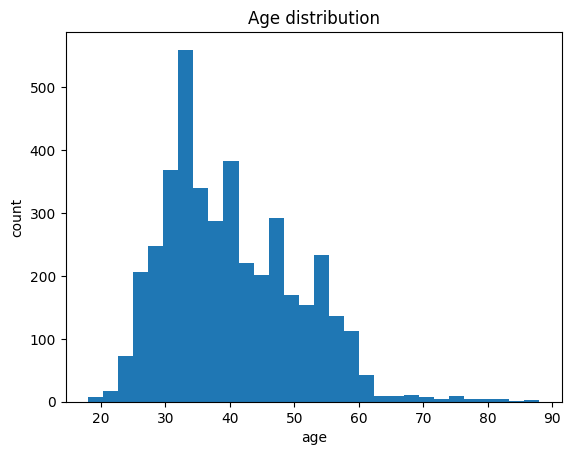

In [148]:
plt.hist(df["age"], bins=30)
plt.title("Age distribution")
plt.xlabel("age"); plt.ylabel("count")
plt.show()

**age**: Tends to cluster around ~34-36, and is right-skewed with minimal customers being over ~60
* Common age range: ~30-55 years old

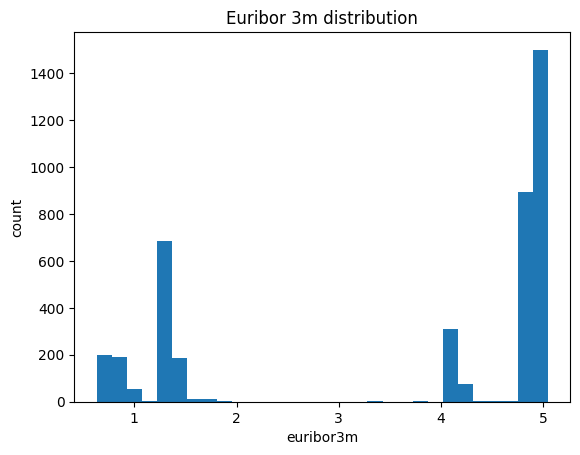

In [149]:
plt.hist(df["euribor3m"], bins=30)
plt.title("Euribor 3m distribution")
plt.xlabel("euribor3m"); plt.ylabel("count")
plt.show()

**euribor3m**: Interest rate at which European banks lend money to each other for 3 months
* Short-term interest rate benchmark in the Eurozone
* Cluster around 1% and another jump at 5%

**euribor3m = 1**
* 1% interest rate
* Borrowing money is cheap
* Clients could be less motivated to put money into term deposits
* Prefer high-return investments

**euribor3m = 5**
* 5% interest rate
* Borrowing money is expensive
* Savings accounts and deposits offer better returns
* Clients could be more motivated to subscribe to a term deposit

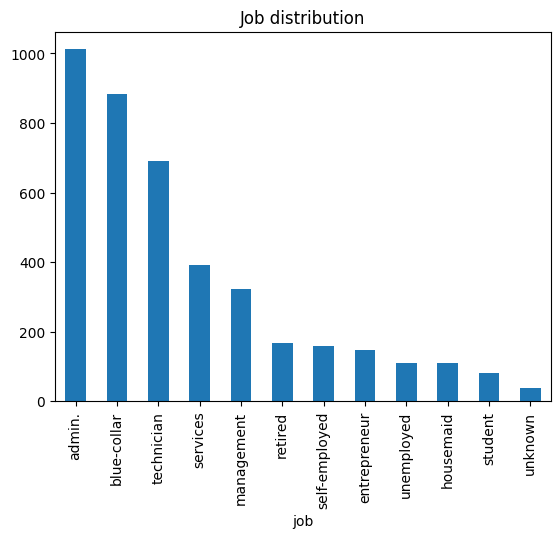

In [150]:
df["job"].value_counts().plot(kind="bar")
plt.title("Job distribution")
plt.show()

**job**: more than ~half of the careers are made up of admin, blue-collar, and technician
* Small population of customers from retired-unknown
* Right skewed

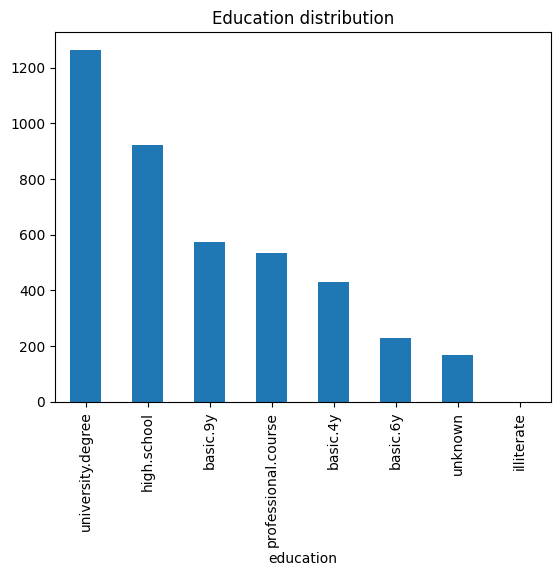

In [151]:
df["education"].value_counts().plot(kind="bar")
plt.title("Education distribution")
plt.show()

**Education:** university > high school > basic 9y > professional course > basic 4y > basic 6y > unknown > illiterate
* Customers are mostly made up of those who have a high school and university degrees
* Right-skewed

# 3. Data splitting

Split the dataset into:
- 60% training
- 20% validation
- 20% test  
with stratification to preserve the class ratio.

## Why Splitting is Here
Splitting must happen before any preprocessing that learns from data (encoding/scaling/resampling).
Otherwise we would leak information from validation/test into training.

### Scaling before splitting
- We do NOT do this because then the mean and standard deviation from validation would leak into training
### If we resampled before splitting
- Duplicates could appear in the validation/testing

In [152]:
X = df.drop(columns=["y"])
y = df["y"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Sizes:", len(X_train), len(X_val), len(X_test))

Sizes: 2471 824 824


In [153]:
print("Original:\n", y.value_counts(normalize=True))
print("\nTrain:\n", y_train.value_counts(normalize=True))
print("\nVal:\n", y_val.value_counts(normalize=True))
print("\nTest:\n", y_test.value_counts(normalize=True))

Original:
 y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Train:
 y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64

Val:
 y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64

Test:
 y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64


# 4. Managing missing values

- We will use the training set for determining missingness.
- We will not “fit” missingness handling on validation/test.

## Why 4 Managing Missing Values is Here
Missing-value handling decisions can depend on data frequencies (like how often "unknown" appears).
Those decisions must be based on training only to avoid leakage into validation/test.

In [154]:
missing_report = []
for col in unknown_cols:
    n_unknown = (X_train[col] == "unknown").sum()
    pct_unknown = (X_train[col] == "unknown").mean()
    missing_report.append((col, n_unknown, pct_unknown))

missing_train_df = pd.DataFrame(
    missing_report,
    columns=["column", "n_unknown_in_train", "pct_unknown_in_train"]
).sort_values("pct_unknown_in_train", ascending=False)

display(missing_train_df)

,column,n_unknown_in_train,pct_unknown_in_train
3,default,492,0.199110
2,education,104,0.042088
4,housing,55,0.022258
5,loan,55,0.022258
0,job,20,0.008094
1,marital,7,0.002833


### Strategy chosen
We keep **"unknown"** as its own category instead of replacing it, because:
- **unknown** is not random noise
- One-hot encoding can represent **unknown** explicitly (e.g.,**job_unknown**).
- There are no explicit NaNs that require imputation.

# 5. Feature selection
- We remove the features that violate prediction-time constraints.

## Why Feature Selection Here
We remove invalid features before encoding/scaling so that:
- We don’t waste processing on unusable features.
- The final feature set is consistent across train/val/test.
- If we did feature selection **before** splitting, we would introduce optimistic bias into our validation/test sets

###Variables:
- age
- job
- marital
- education
- default
- housing
- loan
- contact
- month
- day_of_week
- duration
- campaign
- pdays
- previous
- poutcome
- emp.var.rate
- cons.price.idx
- cons.conf.idx
- euribor3m
- nr.employed

### Variables to remove:
- Duration

### Why?
- We only know the length of duration after the phone call
- This is temporal leakage

The rest of the variables are valid for our dataset

In [155]:
leakage_features = ["duration"]

X_train_fs = X_train.drop(columns=leakage_features)
X_val_fs   = X_val.drop(columns=leakage_features)
X_test_fs  = X_test.drop(columns=leakage_features)

In [156]:
num_cols_fs = X_train_fs.select_dtypes(include=["int64", "float64"]).columns.tolist()
variances = X_train_fs[num_cols_fs].var()

low_var_threshold = 1e-6
low_var_features = variances[variances < low_var_threshold].index.tolist()

print("Low variance numeric features:", low_var_features)

Low variance numeric features: []


In [157]:
corr = X_train_fs[num_cols_fs].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

corr_threshold = 0.95
high_corr_pairs = [
    (row, col, upper.loc[row, col])
    for row in upper.index
    for col in upper.columns
    if pd.notnull(upper.loc[row, col]) and upper.loc[row, col] > corr_threshold
]

high_corr_pairs[:10], len(high_corr_pairs)

([('emp.var.rate', 'euribor3m', np.float64(0.9700126574780245))], 1)

Since **low_var_features** is empty, that means no numeric feature has near-zero variance, so we do not remove any for that reason.

Since **high_corr_pairs** is non-empty, we would drop one feature from each highly correlated pair to reduce redundancy.

We compute correlation using training only to avoid leakage.

# 6. Encoding Categorical Variables

## What we do here
Convert categorical variables into numeric form using One-Hot Encoding.

## Why Encoding is Here
- Logistic Regression requires numeric inputs.
- Encoding must happen AFTER feature selection so that only valid features are encoded.
- The encoder must be fit on the TRAINING set only to avoid leakage.

In [158]:
cat_cols = X_train_fs.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


We will transform these columns using one hot encoding so our model can understand the categorical columns as numbers

In [159]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit on TRAINING data only
ohe.fit(X_train_fs[cat_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

- fit() learns the categories that exist in training data
- handle_unknown="ignore" prevents crashes if new categories appear later

In [160]:
X_train_ohe = pd.DataFrame(
    ohe.transform(X_train_fs[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train_fs.index
)

X_val_ohe = pd.DataFrame(
    ohe.transform(X_val_fs[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_val_fs.index
)

X_test_ohe = pd.DataFrame(
    ohe.transform(X_test_fs[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test_fs.index
)

print("Original categorical features:", len(cat_cols))
print("Encoded categorical features:", X_train_ohe.shape[1])

Original categorical features: 10
Encoded categorical features: 53


- We greatly increased our dimensionality
- Now logistic regression can assign different weights per category

# 7. Feature Scaling

Here we will scale the numerical variables using standardization (using z-score scaling).

## Why Feature Scaling is Here
- Logistic Regression is sensitive to the magnitude of input features.
- Without scaling, features with larger numeric ranges dominate optimization.
- Scaling must be fit on the training set only to prevent leakage.
- We perform scaling AFTER encoding and feature selection because we now know the final set of numeric variables.

## Mathematical reason
Standardization transforms each numeric feature as:

    x_scaled = (x - mean_train) / std_train

This ensures:
- Mean ≈ 0
- Standard deviation ≈ 1

This improves:
- Gradient-based optimization stability
- Comparability of coefficients
- Fairness of regularization penalties

In [161]:
# Identify numeric columns AFTER feature selection
num_cols = X_train_fs.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numeric columns to scale:")
print(num_cols)

Numeric columns to scale:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


Here we choose to use the **standard scaler** since Logistic Regression is sensitive to the scale of numerical features.

We transformt he mean = 0, and the standard deviation = 1 so we can put each numerical feature on the same scale. This improves interpretatibility and ensures regularization penalizes features fairly.

In [162]:
scaler = StandardScaler()

scaler.fit(X_train_fs[num_cols])

StandardScaler()

In [163]:
X_train_num = pd.DataFrame(
    scaler.transform(X_train_fs[num_cols]),
    columns=num_cols,
    index=X_train_fs.index
)

X_val_num = pd.DataFrame(
    scaler.transform(X_val_fs[num_cols]),
    columns=num_cols,
    index=X_val_fs.index
)

X_test_num = pd.DataFrame(
    scaler.transform(X_test_fs[num_cols]),
    columns=num_cols,
    index=X_test_fs.index
)

Here we apply the scaler to our training, validation, and test sets so that we measure the variables based on standard deviations and not their true values.

We output this back into a table format like we originally had so that it is easier for our model to read and understand.

This ensures that all variables as well as sets are judged fairly and on the same scale.

In [164]:
X_train_final = pd.concat([X_train_num, X_train_ohe], axis=1)
X_val_final   = pd.concat([X_val_num,   X_val_ohe],   axis=1)
X_test_final  = pd.concat([X_test_num,  X_test_ohe],  axis=1)

print("Final feature matrix shape:")
print("Train:", X_train_final.shape)
print("Validation:", X_val_final.shape)
print("Test:", X_test_final.shape)

Final feature matrix shape:
Train: (2471, 62)
Validation: (824, 62)
Test: (824, 62)


Here we put all of our transformed data from two separate places into one place.

We see our final split:
- Training 60%
  - 2471 rows/clients
  - 62 columns/features
- Validation & Test 20%
  - 824 rows/clients
  - 62 columns/features

After scaling:
- All numeric variables have comparable magnitude
- Have unbiased logistic regression optimization
- Regularization (L2) will treat coefficients more fairly

# 8. Addressing Class Imbalance

We quantify the imbalance in the training set and apply random oversampling to balance the classes.

## Why Class Imbalance is Here
- Resampling is part of training, not evaluation.
- This occurs AFTER preprocessing.
- It must affect only the training set.
- Validation and test sets must preserve the original distribution.

In [165]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

Training class distribution:
y
no     2200
yes     271
Name: count, dtype: int64

Training class proportions:
y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64


The training set is imbalanced, with significantly more "no" than "yes" cases.
This means a model can achieve high accuracy by predicting "no" most of the time.

Therefore, accuracy alone is not a sufficient metric.

In [166]:
train_df = X_train_final.copy()
train_df["y"] = y_train.values

majority = train_df[train_df["y"] == "no"]
minority = train_df[train_df["y"] == "yes"]

minority_upsampled = minority.sample(
    n=len(majority),
    replace=True,
    random_state=42
)

train_balanced = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42)

X_train_bal = train_balanced.drop(columns=["y"])
y_train_bal = train_balanced["y"]

print("Balanced training distribution:")
print(y_train_bal.value_counts())

Balanced training distribution:
y
no     2200
yes    2200
Name: count, dtype: int64


Random oversampling duplicates minority class examples so that the model sees equal representation of both classes during training.

If we applied oversampling before splitting, duplicated samples could appear in validation/test, leading to artificially inflated performance.

Therefore, oversampling is applied ONLY to the training set.

# 9. Training Logistic Regression

Train a Logistic Regression model using the balanced training set.

## Why Training is Here
- All preprocessing is complete.
- The model should only see processed training data.
- The goal is to verify that the pipeline behaves coherently.

In [167]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_bal, y_train_bal)

LogisticRegression(max_iter=1000)

Here we train the model:
- The model can take 1000 max steps to learn
- Logistic Regression adjusts weights step-by-step
  - For each feature the model learns a weight, and adjusts the weights until prediction error is minimized

# 10. Evaluation + Zero Rule Comparison
- Compute Zero Rule baseline.
- Evaluate Logistic Regression on validation set.
- Report Accuracy, Precision, Recall.
- Display confusion matrix.

## Why Evaluation is Here
- Final visualizations after cleaning data and training our model

In [168]:
most_common = y_train.value_counts().idxmax()
y_val_pred_zero = np.array([most_common] * len(y_val))

zero_acc = accuracy_score(y_val, y_val_pred_zero)
print("Zero Rule validation accuracy:", zero_acc)

Zero Rule validation accuracy: 0.8907766990291263


In [169]:
y_val_pred = lr.predict(X_val_final)

acc  = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, pos_label="yes")
rec  = recall_score(y_val, y_val_pred, pos_label="yes")

print("LogReg validation accuracy:", acc)
print("LogReg validation precision:", prec)
print("LogReg validation recall:", rec)

LogReg validation accuracy: 0.8264563106796117
LogReg validation precision: 0.3374233128834356
LogReg validation recall: 0.6111111111111112


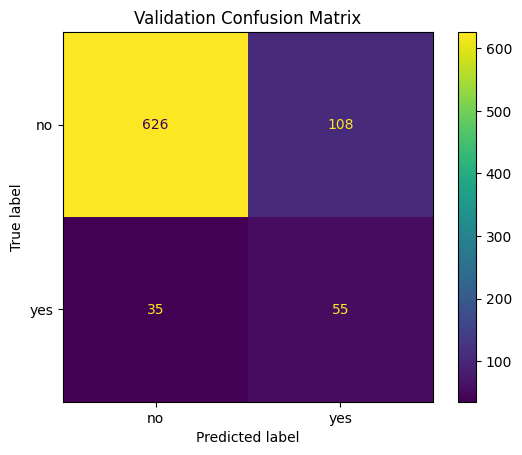

In [170]:
cm = confusion_matrix(y_val, y_val_pred, labels=["no", "yes"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])
disp.plot()
plt.title("Validation Confusion Matrix")
plt.show()

# Interpretation of Validation Results

The Zero Rule baseline achieves 89% accuracy by always predicting "no", which reflects the class imbalance.

Logistic Regression achieves lower accuracy 82.6% but significantly higher recall 61.1% for the minority class.

This means:
- The model successfully identifies many subscribers.
- However, it produces a substantial number of false positives, leading to low precision 33.7%.

In an imbalanced marketing dataset, recall may be more important than raw accuracy, since failing to identify a potential subscriber may be more costly than contacting a non-subscriber.

Disclaimer:

Code and explanations were fact checked alongside ChatGPT